In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn import tree
import matplotlib.pyplot as plt


In [ ]:
import pandas as pd

data = {
    'weather': ['sunny','cloudy','sunny','cloudy','Rainy',
                'Rainy','Rainy','sunny','cloudy','Rainy'],

    'Temprature': ['hot','hot','hot','mild','cool',
                   'cool','mild','cool','mild','hot'],

    'humidity': ['high','high','high','high','normal',
                 'normal','normal','high','normal','high'],

    'wind': ['weak','strong','weak','weak','weak',
             'strong','strong','weak','weak','strong'],

    'play': ['no','yes','yes','yes','no',
             'no','yes','no','yes','no']
}

df = pd.DataFrame(data)
print(df)

  weather Temprature humidity    wind play
0   sunny        hot     high    weak   no
1  cloudy        hot     high  strong  yes
2   sunny        hot     high    weak  yes
3  cloudy       mild     high    weak  yes
4   Rainy       cool   normal    weak   no
5   Rainy       cool   normal  strong   no
6   Rainy       mild   normal  strong  yes
7   sunny       cool     high    weak   no
8  cloudy       mild   normal    weak  yes
9   Rainy        hot     high  strong   no


In [ ]:
encoder ={}
for col in df.columns:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])
  encoder[col] = le
df

,weather,Temprature,humidity,wind,play
0,2,1,0,1,0
1,1,1,0,0,1
2,2,1,0,1,1
3,1,2,0,1,1
4,0,0,1,1,0
5,0,0,1,0,0
6,0,2,1,0,1
7,2,0,0,1,0
8,1,2,1,1,1
9,0,1,0,0,0


In [ ]:
x = df.drop('play',axis = 1)
y = df['play']

In [ ]:
print("Features")
print(x)

Features
   weather  Temprature  humidity  wind
0        2           1         0     1
1        1           1         0     0
2        2           1         0     1
3        1           2         0     1
4        0           0         1     1
5        0           0         1     0
6        0           2         1     0
7        2           0         0     1
8        1           2         1     1
9        0           1         0     0


In [ ]:
model  = DecisionTreeClassifier(
    criterion = 'entropy',
    random_state= 42
)

In [ ]:
model.fit(x,y)
print("model trained sucessfully")

model trained sucessfully


In [ ]:


from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(x, y)

importance = model.feature_importances_

for feature, score in zip(x.columns, importance):
    print(feature, ":", score)

weather : 0.25
Temprature : 0.7499999999999999
humidity : 0.0
wind : 0.0


In [ ]:
new_data = pd.DataFrame({
    'weather': ['sunny'],
    'Temprature': ['mild'],
    'humidity': ['normal'],
    'wind': ['strong']
})
new_data

,weather,Temprature,humidity,wind
0,sunny,mild,normal,strong


In [ ]:
for col in new_data.columns:
    new_data[col] = encoder[col].transform(new_data[col])

prediction = model.predict(new_data)
result = encoder['play'].inverse_transform(prediction)

print(result[0])

yes


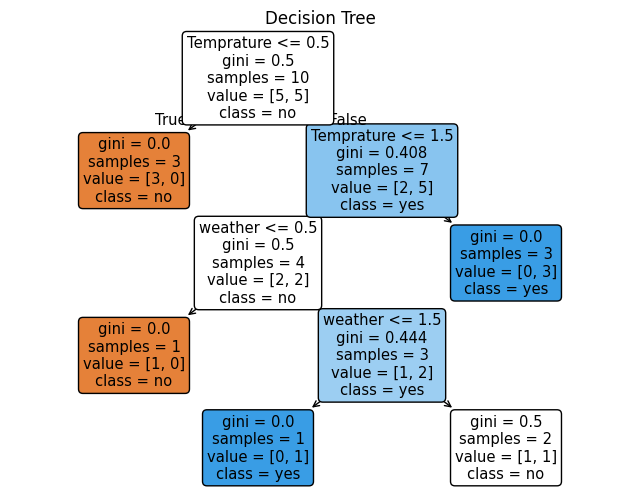

In [ ]:
plt.figure(figsize=(8,6))
plot_tree(model,feature_names=x.columns,class_names=['no','yes'],
          filled=True,rounded=True)

plt.title("Decision Tree")
plt.show()